 ÉTAPE 1 — Charger les données

In [115]:
import pandas as pd
import numpy as np
import os
from dotenv import load_dotenv
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Charger les variables d'environnement
load_dotenv('../.env') 
path = os.getenv('RAW_DATA_PATH')

# 2. Charger les données (ton fichier .csv)
df = pd.read_csv(f"../{path}")

df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.lower()


print("Données chargées !")

Données chargées !


ÉTAPE 2 — Explorer les données

In [116]:
print("\nShape du dataset :", df.shape)
#Nombre de lignes/colonnes
print("\nInformations générales :")
df.info()
#Types + valeurs manquantes
print("\nStatistiques descriptives :")
print(df.describe())
#Statistiques descriptives pour les colonnes numériques
print("\nValeurs manquantes :")
print(df.isnull().sum())
#Détecter les NaN


Shape du dataset : (4372, 52)

Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4372 entries, 0 to 4371
Data columns (total 52 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerid                 4372 non-null   int64  
 1   recency                    4372 non-null   int64  
 2   frequency                  4372 non-null   int64  
 3   monetarytotal              4372 non-null   float64
 4   monetaryavg                4372 non-null   float64
 5   monetarystd                4372 non-null   float64
 6   monetarymin                4372 non-null   float64
 7   monetarymax                4372 non-null   float64
 8   totalquantity              4372 non-null   int64  
 9   avgquantitypertransaction  4372 non-null   float64
 10  minquantity                4372 non-null   int64  
 11  maxquantity                4372 non-null   int64  
 12  customertenuredays         4372 non-null   int6

ÉTAPE 3 — Visualisation des données

1. Visualisation globale

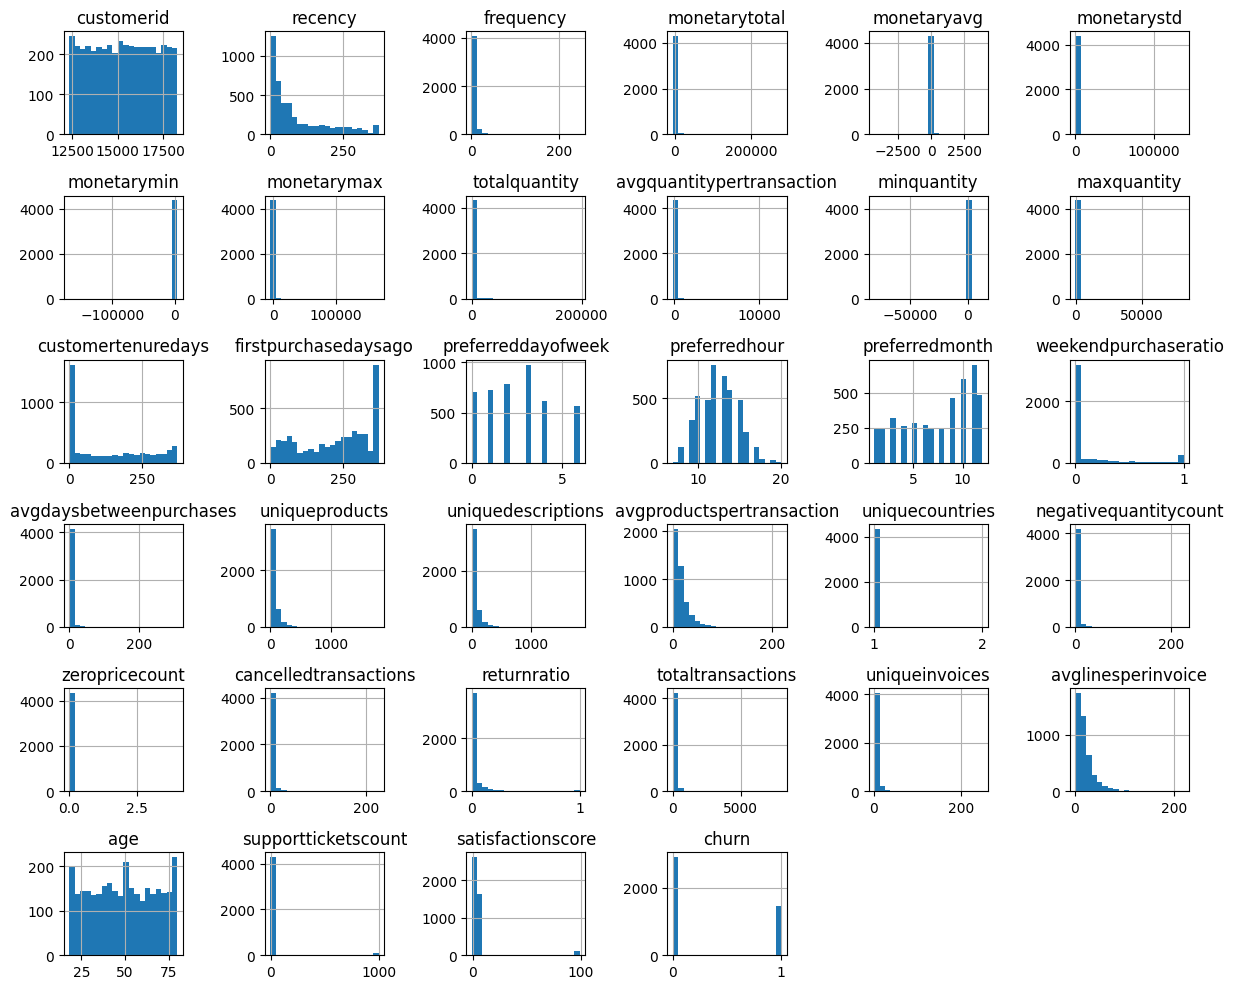

In [117]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

# Aperçu des données

In [118]:
print("=== Aperçu des données ===")
display(df.head())
display(df.sample(5))

=== Aperçu des données ===


,customerid,recency,frequency,monetarytotal,monetaryavg,monetarystd,monetarymin,monetarymax,totalquantity,avgquantitypertransaction,...,region,loyaltylevel,churnriskcategory,weekendpreference,basketsizecategory,productdiversity,gender,accountstatus,country,churn
0,17850,302,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,...,UK,Jeune,Critique,Inconnu,Moyen,Explorateur,Unknown,Active,United Kingdom,1
1,13047,32,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,...,UK,Établi,Moyen,Semaine,Moyen,Explorateur,M,Active,United Kingdom,0
2,12583,3,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,...,Europe continentale,Ancien,Faible,Semaine,Grand,Explorateur,Unknown,Active,France,0
3,13748,96,5,948.25,33.866071,42.953119,9.36,204.00,439,15.678571,...,UK,Établi,Critique,Inconnu,Grand,Explorateur,Unknown,Active,United Kingdom,1
4,15100,330,6,635.10,105.850000,215.986263,-131.40,350.40,58,9.666667,...,UK,Jeune,Critique,Inconnu,Moyen,Spécialisé,M,Active,United Kingdom,1


,customerid,recency,frequency,monetarytotal,monetaryavg,monetarystd,monetarymin,monetarymax,totalquantity,avgquantitypertransaction,...,region,loyaltylevel,churnriskcategory,weekendpreference,basketsizecategory,productdiversity,gender,accountstatus,country,churn
980,12503,338,1,-1126.00,-1126.000000,0.000000,-1126.00,-1126.0,-1,-1.000000,...,Europe continentale,Nouveau,Critique,Inconnu,Petit,Spécialisé,Unknown,Pending,Spain,1
204,17961,21,39,1296.44,5.206586,9.175426,0.29,125.0,560,2.248996,...,UK,Établi,Faible,Semaine,Petit,Explorateur,Unknown,Active,United Kingdom,0
1995,16672,2,23,8093.59,69.175983,46.054316,-26.10,226.8,2812,24.034188,...,UK,Établi,Faible,Inconnu,Grand,Explorateur,F,Active,United Kingdom,0
2287,15775,245,1,104.90,14.985714,2.391951,10.20,17.7,68,9.714286,...,UK,Nouveau,Critique,Inconnu,Moyen,Modéré,Unknown,Active,United Kingdom,1
3486,13323,3,5,787.85,37.516667,42.103739,14.85,204.0,175,8.333333,...,UK,Jeune,Faible,Inconnu,Moyen,Modéré,Unknown,Active,United Kingdom,0


# Colonnes et cardinalité

In [119]:
print("\n=== Colonnes et nombre de valeurs uniques ===")
for col, n in zip(df.columns, df.nunique()):
    print(f"{col}: {n} valeurs uniques")


=== Colonnes et nombre de valeurs uniques ===
customerid: 4372 valeurs uniques
recency: 349 valeurs uniques
frequency: 65 valeurs uniques
monetarytotal: 4295 valeurs uniques
monetaryavg: 4330 valeurs uniques
monetarystd: 4277 valeurs uniques
monetarymin: 833 valeurs uniques
monetarymax: 852 valeurs uniques
totalquantity: 1788 valeurs uniques
avgquantitypertransaction: 3550 valeurs uniques
minquantity: 141 valeurs uniques
maxquantity: 159 valeurs uniques
customertenuredays: 374 valeurs uniques
firstpurchasedaysago: 357 valeurs uniques
preferreddayofweek: 6 valeurs uniques
preferredhour: 14 valeurs uniques
preferredmonth: 12 valeurs uniques
weekendpurchaseratio: 855 valeurs uniques
avgdaysbetweenpurchases: 2640 valeurs uniques
uniqueproducts: 342 valeurs uniques
uniquedescriptions: 333 valeurs uniques
avgproductspertransaction: 1027 valeurs uniques
uniquecountries: 2 valeurs uniques
negativequantitycount: 54 valeurs uniques
zeropricecount: 4 valeurs uniques
cancelledtransactions: 54 val

# Doublons et unicité

In [120]:
print("\n=== Doublons et unicité ===")
print("Nombre de doublons :", df.duplicated().sum())
if 'CustomerID' in df.columns:
    print("CustomerID unique ?", df['CustomerID'].is_unique)


=== Doublons et unicité ===
Nombre de doublons : 0


# Vérification des bornes pour colonnes critiques

In [121]:
num_cols = ['Age', 'SupportTicketsCount', 'MonetaryTotal']
print("\n=== Vérification des bornes numériques ===")
for col in num_cols:
    if col in df.columns:
        print(f"{col}: min={df[col].min()}, max={df[col].max()}")


=== Vérification des bornes numériques ===


In [122]:
# 2. Log transformation
# df['MonetaryTotal'].hist()
# plt.title("Avant transformation")
# plt.show()

# df['MonetaryTotal_log'] = np.log1p(df['MonetaryTotal'].clip(lower=0))

# df['MonetaryTotal_log'].hist()
# plt.title("Après transformation")
# plt.show()


In [123]:
cat_cols = df.select_dtypes(include=['object']).columns
print("\n=== Colonnes catégorielles et cardinalité ===")
for col in cat_cols:
    n_unique = df[col].nunique()
    print(f"{col}: {n_unique} valeurs uniques")
    print(df[col].value_counts().head(5))
    print("-"*40)



=== Colonnes catégorielles et cardinalité ===
registrationdate: 1700 valeurs uniques
registrationdate
12/10/2010    11
2010-12-21    11
01/01/2011    10
10/01/11      10
2010-12-22    10
Name: count, dtype: int64
----------------------------------------
newslettersubscribed: 1 valeurs uniques
newslettersubscribed
Yes    4372
Name: count, dtype: int64
----------------------------------------
lastloginip: 4372 valeurs uniques
lastloginip
59.252.219.201    1
77.255.247.14     1
51.139.78.80      1
10.212.80.124     1
186.34.121.80     1
Name: count, dtype: int64
----------------------------------------
rfmsegment: 4 valeurs uniques
rfmsegment
Potentiels    1589
Fidèles       1177
Champions      979
Dormants       627
Name: count, dtype: int64
----------------------------------------
agecategory: 7 valeurs uniques
agecategory
Inconnu    1311
65+         791
45-54       515
35-44       495
25-34       474
Name: count, dtype: int64
----------------------------------------
spendingcategory: 

# Analyse de la target


=== Distribution de Churn ===
churn
0    0.667429
1    0.332571
Name: proportion, dtype: float64


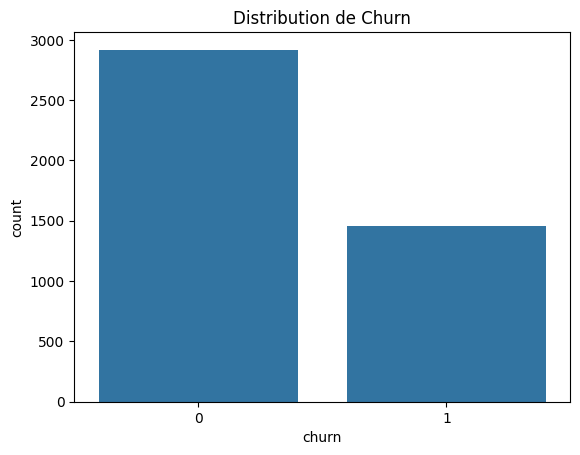

In [124]:
print("\n=== Distribution de Churn ===")
print(df['churn'].value_counts(normalize=True))


sns.countplot(x='churn', data=df)
plt.title("Distribution de Churn")
plt.show()


# Corrélation

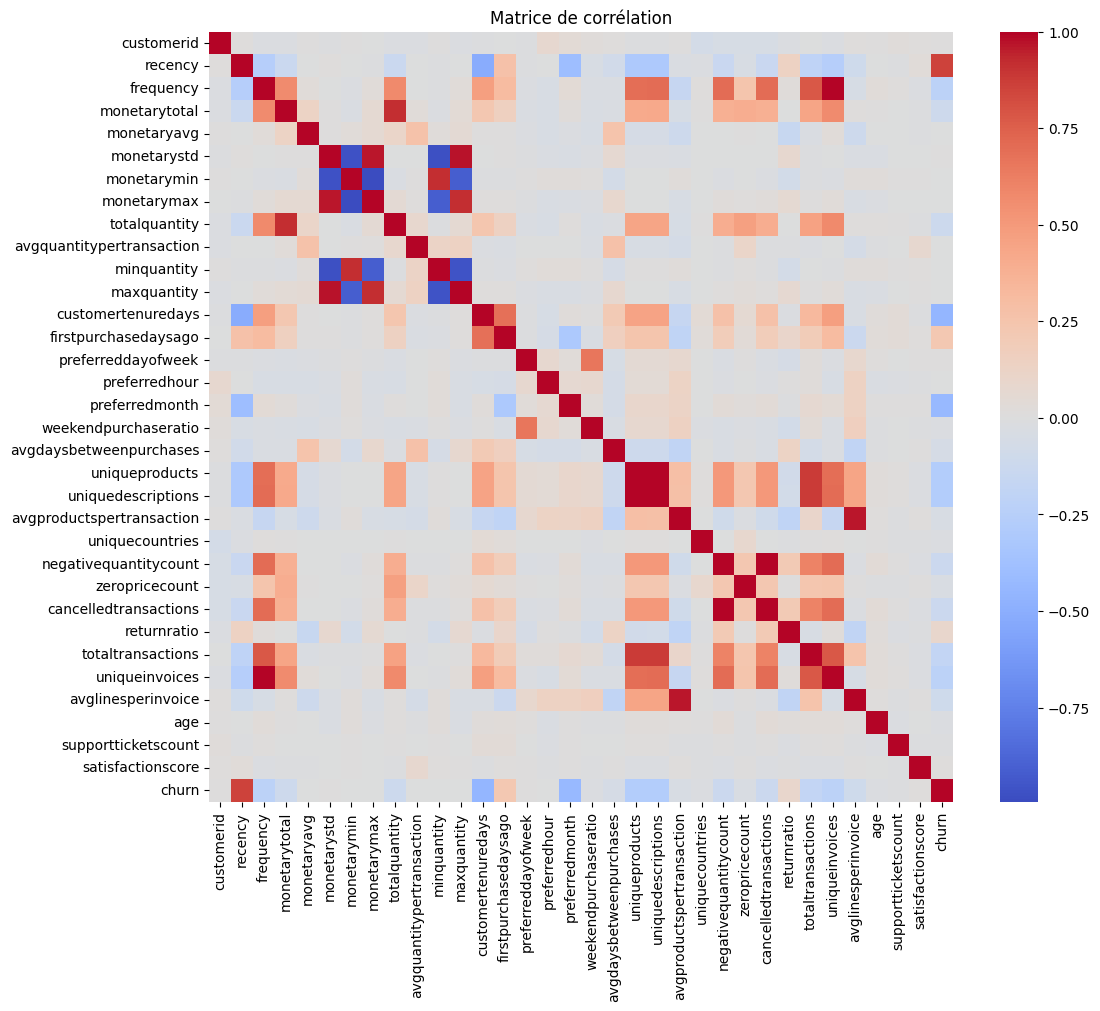

In [125]:
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()


In [126]:
print("\n=== Corrélations fortes (>0.8) ===")

import numpy as np

corr_matrix = df.corr(numeric_only=True).abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

for col in upper.columns:
    high_corr = upper[col][upper[col] > 0.8]
    if not high_corr.empty:
        print(f"{col} corrélé avec {list(high_corr.index)}")



=== Corrélations fortes (>0.8) ===
monetarymin corrélé avec ['monetarystd']
monetarymax corrélé avec ['monetarystd', 'monetarymin']
totalquantity corrélé avec ['monetarytotal']
minquantity corrélé avec ['monetarystd', 'monetarymin', 'monetarymax']
maxquantity corrélé avec ['monetarystd', 'monetarymin', 'monetarymax', 'minquantity']
uniquedescriptions corrélé avec ['uniqueproducts']
cancelledtransactions corrélé avec ['negativequantitycount']
totaltransactions corrélé avec ['uniqueproducts', 'uniquedescriptions']
uniqueinvoices corrélé avec ['frequency']
avglinesperinvoice corrélé avec ['avgproductspertransaction']
churn corrélé avec ['recency']


# Analyse des outliers

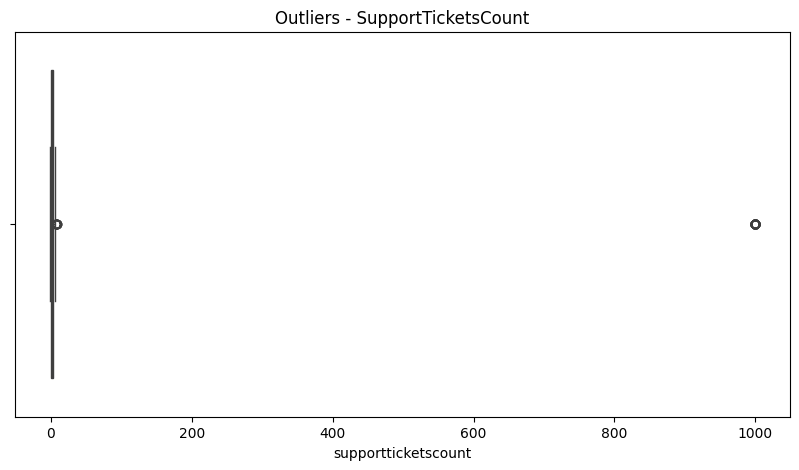

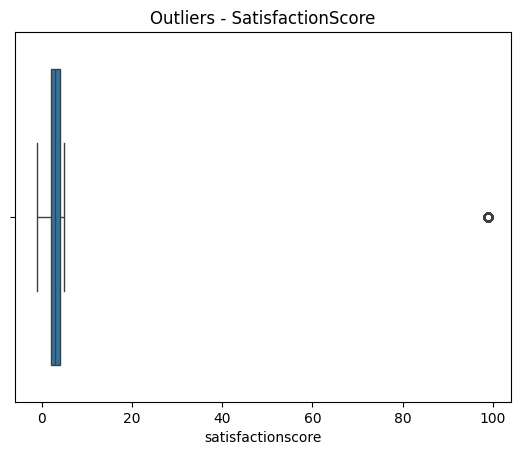

In [127]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['supportticketscount'])
plt.title("Outliers - SupportTicketsCount")
plt.show()

sns.boxplot(x=df['satisfactionscore'])
plt.title("Outliers - SatisfactionScore")
plt.show()


# Analyse RFM

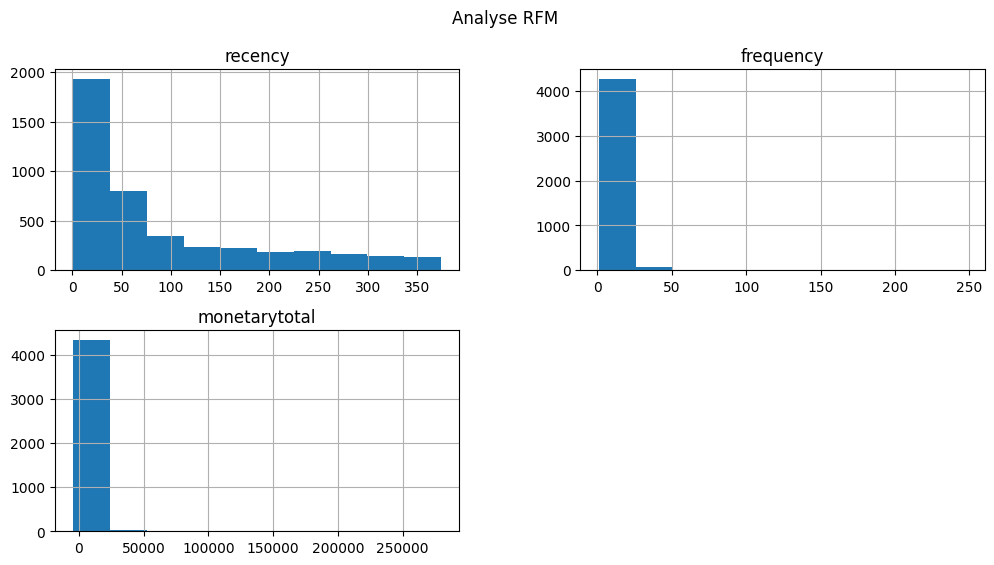

In [128]:
cols = ['recency', 'frequency', 'monetarytotal']

df[cols].hist(figsize=(12,6))
plt.suptitle("Analyse RFM")
plt.show()


Sauvegarde pour étape suivante

In [129]:
output_path = "../data/processed/step1_exploration.csv"
df.to_csv(output_path, index=False)

print(f"Données sauvegardées dans : {output_path}")

Données sauvegardées dans : ../data/processed/step1_exploration.csv


In [130]:
print(f"""
INSIGHTS :

- Dataset contient {df.shape[0]} lignes et {df.shape[1]} colonnes
- Présence de valeurs manquantes dans Age
- Déséquilibre de Churn : {df['churn'].value_counts(normalize=True).to_dict()}
- Corrélations fortes détectées entre certaines variables
- Présence d’outliers dans SupportTickets et Satisfaction
""")



INSIGHTS :

- Dataset contient 4372 lignes et 52 colonnes
- Présence de valeurs manquantes dans Age
- Déséquilibre de Churn : {0: 0.6674290942360476, 1: 0.33257090576395243}
- Corrélations fortes détectées entre certaines variables
- Présence d’outliers dans SupportTickets et Satisfaction

